# Import Paper Summary Data

In [9]:
import pandas as pd

# Load the data
df = pd.read_csv(
    "data/papers_summary.csv",
    usecols=lambda col: not col.startswith("Unnamed:")
)

df

,Application,Title,Authors,Year,Keywords,Abstract,Platform,Project Type,Model,Description,Database
0,P2P Energy Trading,A Lockable ERC20 Token for Peer to Peer Energy...,"Liana Toderean, Claudia Antal, Marcel Antal, D...",2021,"Blockchain, Energy Token, ERC20, Lockable,\r\n...","In this paper, we address the digitization of ...",Ethereum,Conference Paper,LockableERC20,Token Smart contract details designed but not...,IEEE
1,P2P Energy Trading,Tokenization of energy assets: A\r\nmultichain...,"R. Akiladevi, S. Sardha, and R. Shruthi,",2024,"Blockchain Technology, Green Energy, Token\r\n...",The biggest barrier is the financial strain ca...,Multichain,Conference Paper,NaN,No smart contract designed,IEEE
2,P2P Energy Trading,An Efficient Algorithm for Peer-to-Peer Energy...,"Nahid-Ur-Rahman Chowdhury, Khairul Islam, and ...",2019,"Peer-to-Peer Energy Trading, Blockchain,\r\nMi...",Electricity generation from distributed renewa...,NaN,Journal,NaN,Algorithms designed without implementation,European Journal of Electrical Engineering and...
3,P2P Energy Trading,ZipZap: A Blockchain Solution for Local Energy...,"Mario Felipe Munoz, Kaiwen Zhang and Fatima Amara",2022,"Blockchain, Smart Contract, Energy Tokenizatio...","In the last few years, electric utility compan...",Ethereum (Quorum),Conference Paper,ERC-1155,ZipZap is an\r\nERC-1155 compliant solution wh...,arXiv
4,P2P Energy Trading,Blockchain-Based Peer-to-Peer Energy Trading:D...,"Demiral AKBAR, Mert ÜNAL, Recep AKKAYA, Orkun ...",2025,"Blockchain, Peer-to-Peer Energy Trading, Energ...",This study presents a decentralized energy man...,Ethereum (Hyperledger Besu),Journal,ERC-20,DEMS architecture and functions designed witho...,Wiley
...,...,...,...,...,...,...,...,...,...,...,...
108,RECs and Carbon Tracking,Blockchain-Oracle-Enabled Energy Settlement In...,Peyman Zare; SeyedJalal SeyedShenava; Hossein ...,2026,"Carbon Emission Trading, Eco-Industrial Park, ...",The increasing integration of renewable genera...,Blockchain with oracle-enabled settlement; exa...,Journal,Tokenized carbon and green certificates; stand...,Carbon and green certificates are tokenized wi...,ScienceDirect
109,P2P Energy Trading,A renewable energy microgrids trading manageme...,Yu-Tian Lei; Chao-Qun Ma; Nawazish Mirza; Yi-S...,2022,"Renewable energy, Permissioned blockchain, Tra...",This paper presents an energy trading platform...,Hyperledger Fabric,Journal,Token trading mechanism; standard not specified,Smart contracts implement token trading and ac...,ScienceDirect
110,Flexibility and Demand Response,Blockchain-enabled secure and authentic Nash e...,D.D. Sharma; S.N. Singh; J. Lin,2024,"Network hub, EV token, Heterogeneous blockchai...",In the networked enlarged electric vehicle (EV...,Multiple heterogeneous blockchains; Solidity/P...,Journal,Multiple EV tokens; cross-chain token transfer...,Each EV aggregator can use a different blockch...,ScienceDirect
111,RECs and Carbon Tracking,Chapter 7 - Revolutionizing energy systems: th...,Abdul-Latif Mohammed; Ibrahim Nandom Yakubu,2025,"Blockchain, renewable energy, energy systems",The growth of renewable energy sources has pre...,Multiple blockchain platforms discussed,Book Chapter,General blockchain tokenization; no single tok...,Discusses blockchain as infrastructure for ren...,ScienceDirect


# Plot Stats

## Year

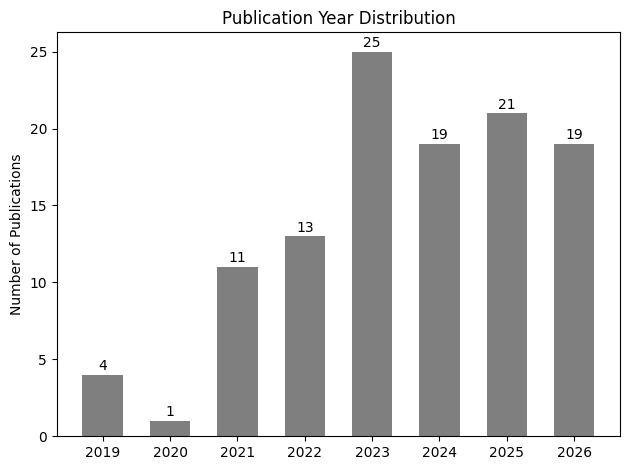

In [5]:
import matplotlib.pyplot as plt

# Convert Year to numeric and remove missing values
years = pd.to_numeric(df["Year"], errors="coerce").dropna().astype(int)

# Count publications by year
year_counts = years.value_counts().sort_index()

# Plot
plt.figure()
bars = plt.bar(
    year_counts.index,
    year_counts.values,
    width=0.6,
    color="tab:grey"
)

# plt.xlabel("Publication Year")
plt.ylabel("Number of Publications")
plt.title("Publication Year Distribution")
plt.xticks(year_counts.index)

# Add number of publications above each bar
for bar in bars:
    count = int(bar.get_height())
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("plots/year_distr.pdf", bbox_inches="tight")
plt.show()

## Publication Type

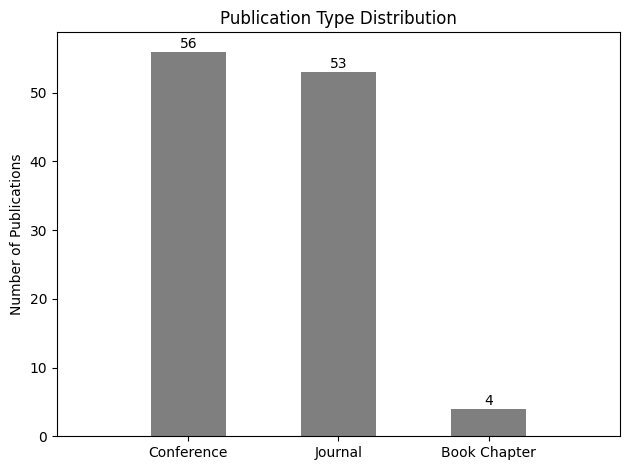

In [40]:
project_counts = df["Project Type"].value_counts()

labels = ["Conference", "Journal", "Book Chapter"]
counts = [
    project_counts.get("Conference Paper", 0),
    project_counts.get("Journal", 0),
    project_counts.get("Book Chapter", 0)
]

# Custom, closely spaced positions
x = [1.2, 2.0, 2.8]

plt.figure()

bars = plt.bar(
    x,
    counts,
    width=0.4,
    color="tab:grey"
)

# Add counts
for bar in bars:
    count = int(bar.get_height())
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.1,
        str(count),
        ha="center",
        va="bottom"
    )

plt.title("Publication Type Distribution")
plt.ylabel("Number of Publications")

# Keep labels aligned with custom positions
plt.xticks(x, labels)

# Optional: make the plot area centered around the bars
plt.xlim(0.5, 3.5)

plt.tight_layout()
plt.savefig("plots/pub_type_distr.pdf", dpi=300)
plt.show()

## Model (ERC Standards) Distribution

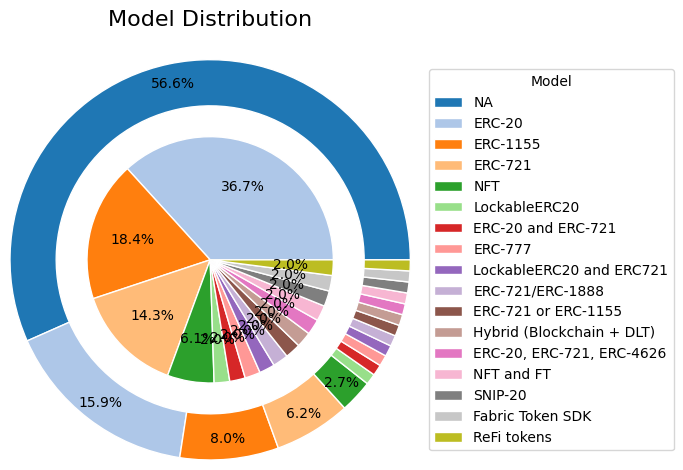

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/papers_summary.csv",
    usecols=lambda col: not col.startswith("Unnamed:")
)
# -------------------------------
# Model Distribution Nested Donut
# -------------------------------

# Clean model column
model_col = df["Model"].fillna("NA").astype(str).str.strip()

# Standardize missing labels
model_col = model_col.replace(
    ["", "nan", "None", "N/A", "NA"],
    "NA"
)

# Outer ring: all models
outer_counts = model_col.value_counts()

# Inner ring: exclude NA
inner_models = model_col[model_col != "NA"]
inner_counts = inner_models.value_counts()

# Consistent colors
labels = outer_counts.index.tolist()

# Create color map
cmap = plt.get_cmap("tab20")
colors = {label: cmap(i) for i, label in enumerate(labels)}

outer_colors = [colors[label] for label in outer_counts.index]
inner_colors = [colors[label] for label in inner_counts.index]

fig, ax = plt.subplots()

# Outer donut (all papers)
ax.pie(
    outer_counts.values,
    radius=1.3,
    labels=None,
    colors=outer_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.90,
    wedgeprops=dict(width=0.30, edgecolor="white")
)

# Inner pie (excluding NA)
ax.pie(
    inner_counts.values,
    radius=0.8,  # smaller radius creates the gap
    labels=None,
    colors=inner_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.65,
    wedgeprops=dict(edgecolor="white")
)

ax.set(aspect="equal")

plt.text(
    0,
    1.45,
    "",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    outer_counts.index,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    title="Model"
)

plt.title("Model Distribution", fontsize=16, pad=30)

plt.tight_layout()
plt.savefig(
    "plots/model_distr.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Platform Distribution

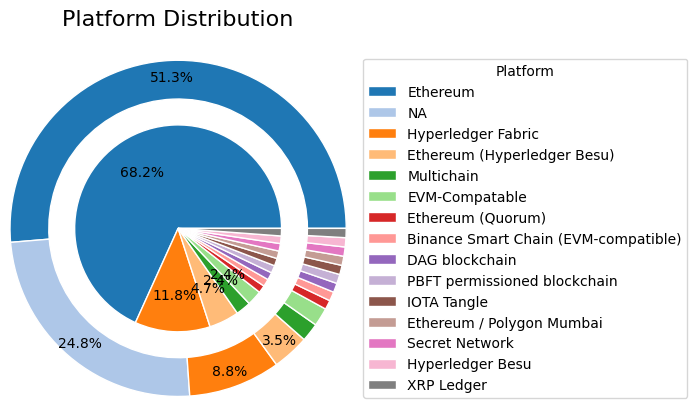

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/papers_summary.csv",
    usecols=lambda col: not col.startswith("Unnamed:")
)
# -------------------------------
# Model Distribution Nested Donut
# -------------------------------

# Clean model column
platform_col = df["Platform"].fillna("NA").astype(str).str.strip()

# Standardize missing labels
platform_col = platform_col.replace(
    ["", "nan", "None", "N/A", "NA"],
    "NA"
)

# Outer ring: all models
outer_counts = platform_col.value_counts()

# Inner ring: exclude NA
inner_platforms = platform_col[platform_col != "NA"]
inner_counts = inner_platforms.value_counts()

# Consistent colors
labels = outer_counts.index.tolist()

# Create color map
cmap = plt.get_cmap("tab20")
colors = {label: cmap(i) for i, label in enumerate(labels)}

outer_colors = [colors[label] for label in outer_counts.index]
inner_colors = [colors[label] for label in inner_counts.index]

fig, ax = plt.subplots()

# Outer donut (all papers)
ax.pie(
    outer_counts.values,
    radius=1.3,
    labels=None,
    colors=outer_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.90,
    wedgeprops=dict(width=0.30, edgecolor="white")
)

# Inner pie (excluding NA)
ax.pie(
    inner_counts.values,
    radius=0.8,  # smaller radius creates the gap
    labels=None,
    colors=inner_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.65,
    wedgeprops=dict(edgecolor="white")
)

ax.set(aspect="equal")

plt.text(
    0,
    1.45,
    "",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    outer_counts.index,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    title="Platform"
)

plt.title("Platform Distribution", fontsize=16, pad=30)

plt.tight_layout()
plt.savefig(
    "plots/platform_distr.pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Application Distribution

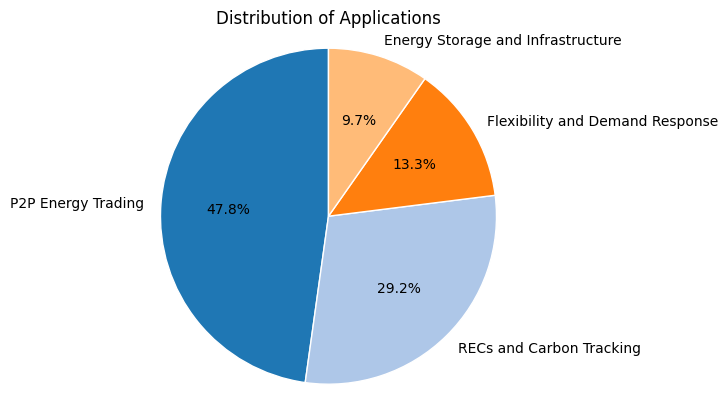

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data/papers_summary.csv",
    usecols=lambda col: not col.startswith("Unnamed:")
)

# Calculate statistics from the Application column
application_counts = df["Application"].dropna().value_counts()

labels = application_counts.index
counts = application_counts.values

# Tableau colors
tab_colors = plt.cm.tab20.colors[:len(counts)]

plt.figure()
plt.pie(
    counts,
    labels=labels,
    colors=tab_colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1
    }
)

plt.title("Distribution of Applications")
plt.axis("equal")
plt.savefig(
    "application_distribution.pdf",
    bbox_inches="tight",
    pad_inches=0.05
)
plt.savefig("plots/application_distr.pdf")
plt.show()

## KeyWord Freq Stats

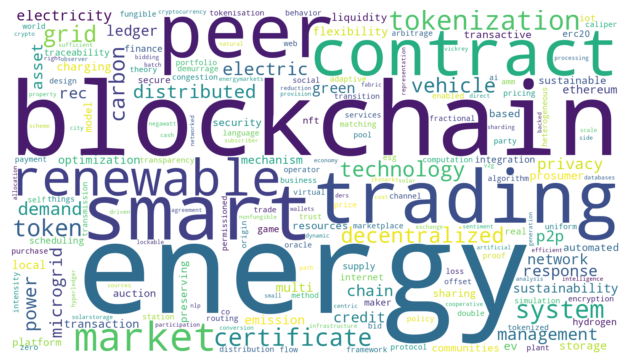

Word cloud saved as: plots/keyword_frequency_cloud.pdf


In [57]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Input Excel file
file_name = "data/papers_summary.csv"

# Read the Excel file
df = pd.read_csv(file_name)

# Check that the Keywords column exists
if "Keywords" not in df.columns:
    raise ValueError("The Excel file does not contain a 'Keywords' column.")

# Collect all keywords
keywords = []

for value in df["Keywords"].dropna():
    # Split keywords by comma
    words = str(value).split(",")

    # Clean and normalize each keyword
    for word in words:
        word = word.strip().lower()

        if word:
            keywords.append(word)

# Join keywords into a single text
keyword_text = " ".join(keywords)

# Add common words to STOPWORDS if needed
stopwords = set(STOPWORDS)

# Generate word cloud
wordcloud = WordCloud(
    width=1600,
    height=900,
    background_color="white",
    stopwords=stopwords,
    max_words=200,
    collocations=False,
    min_font_size=10
).generate(keyword_text)

# Display the word cloud
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()

# Save the image
output_file = "plots/keyword_frequency_cloud.pdf"
plt.savefig(output_file, dpi=300, bbox_inches="tight")

# Show the image
plt.show()

print(f"Word cloud saved as: {output_file}")

# Smart Contract 
ToDo: Re-categorize the functions and highlight the lack of tokenization

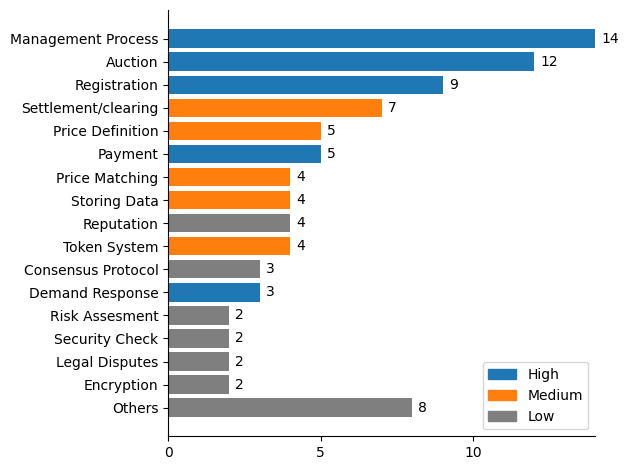

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Define data extracted directly from the chart
categories = [
    "Management Process",
    "Auction",
    "Registration",
    "Settlement/clearing",
    "Price Definition",
    "Payment",
    "Price Matching",
    "Storing Data",
    "Reputation",
    "Token System",
    "Consensus Protocol",
    "Demand Response",
    "Risk Assesment",
    "Security Check",
    "Legal Disputes",
    "Encryption",
    "Others"
]
counts = [14, 12, 9, 7, 5, 5, 4, 4, 4, 4, 3, 3, 2, 2, 2, 2, 8]

# Mapping each category to its specific class color
# Blue = Conventional, Orange = AI-powered / agentic, Gray = Cross-cutting
colors = [
    "#1f77b4",  # Simulation / digital twin
    "#1f77b4",  # Neural network / deep learning
    "#1f77b4",  # LLM / agentic
    "#ff7f0e",  # Field / HRI trials
    "#ff7f0e", # Coverage / test generation
    "#1f77b4",  # Hardware-in-the-loop
    "#ff7f0e",  # Formal / runtime verification
    "#ff7f0e",   # Adversarial / metamorphic
    "#7f7f7f", 
    "#ff7f0e",
    "#7f7f7f",
    "#1f77b4",
    "#7f7f7f",
    "#7f7f7f",
    "#7f7f7f",
    "#7f7f7f",
    "#7f7f7f",
]

# 2. Reverse arrays so the largest item sits at the top of the horizontal bar plot
categories.reverse()
counts.reverse()
colors.reverse()

# 3. Create figure and axis layout
fig, ax = plt.subplots()

# Plot the horizontal bars
bars = ax.barh(categories, counts, color=colors)

# 4. Stylize borders (spines) to match the top-right open look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')

# Set specific X-axis intervals and bounds
ax.set_xticks([0, 5, 10, 15])
ax.set_xlim(0, 14)
# ax.set_xlabel("Publications of different smart contract functionalities classified by the level of relavance to tokenization (n=127), Santos L et.al [2]", fontsize=11, labelpad=4)

# 5. Add text value counters directly next to each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{int(width)}', 
            va='center', ha='left', fontsize=10)

# 6. Construct custom categorical legend 
conventional_patch = mpatches.Patch(color='#1f77b4', label='High')
ai_patch = mpatches.Patch(color='#ff7f0e', label='Medium')
cross_patch = mpatches.Patch(color='#7f7f7f', label='Low')

ax.legend(handles=[conventional_patch, ai_patch, cross_patch], 
          loc='lower right', frameon=True)

# 7. Render plot output neatly
plt.tight_layout()
plt.savefig("plots/sc_func_stats.pdf")
plt.show()
